In [9]:
import os, sys, json
import ray
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

ray.init(
    ignore_reinit_error=True,
    runtime_env={
        "working_dir": "/home/ray/default_cld_g54aiirwj1s8t9ktgzikqur41k/sa-demos/industry-verticals/ecommerce/vlm-batch-embeddings",
        # vLLM 0.20+ moved TokensPrompt up from vllm.inputs.data to vllm.inputs.
        # Ray 2.55's batch LLM stage still imports via the old path, so every
        # worker patches it on startup. Must be set here on ray.init — adding it
        # to a per-actor runtime_env later is silently ignored by Ray's setup-hook
        # registry.
        "worker_process_setup_hook": "src._vllm_compat.patch",
    },
)
print("Cluster resources:", json.dumps(ray.cluster_resources(), indent=2))

2026-05-04 13:40:48,359	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 10.0.64.159:6379...
2026-05-04 13:40:48,388	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at https://session-ixqlsdk9cd4drlzxlswjbh934g.i.anyscaleuserdata.com 
2026-05-04 13:40:48,407	INFO packaging.py:691 -- Creating a file package for local module '/home/ray/default_cld_g54aiirwj1s8t9ktgzikqur41k/sa-demos/industry-verticals/ecommerce/vlm-batch-embeddings'.
2026-05-04 13:40:48,426	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_dc88a5ad18c36145.zip' (4.06MiB) to Ray cluster...
2026-05-04 13:40:48,444	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_dc88a5ad18c36145.zip'.


Cluster resources: {
  "accelerator_type:L4": 3.0,
  "anyscale/provider:aws": 4.0,
  "anyscale/accelerator_shape:1xL4": 3.0,
  "CPU": 32.0,
  "memory": 137438953472.0,
  "object_store_memory": 38452628273.0,
  "anyscale/region:us-west-2": 4.0,
  "GPU": 3.0,
  "node:10.0.65.202": 1.0,
  "anyscale/node-group:1xL4:8CPU-32GB": 3.0,
  "anyscale/node-group:8CPU-32GB": 1.0,
  "node:__internal_head__": 1.0,
  "node:10.0.64.159": 1.0,
  "anyscale/cpu_only:true": 1.0,
  "node:10.0.127.201": 1.0,
  "accelerator_type:L4_group_ae1241e412a92e1aee7712527ab408000000": 0.001,
  "GPU_group_ae1241e412a92e1aee7712527ab408000000": 1.0,
  "GPU_group_0_ae1241e412a92e1aee7712527ab408000000": 1.0,
  "CPU_group_0_ae1241e412a92e1aee7712527ab408000000": 1.0,
  "node:10.0.70.128": 1.0,
  "bundle_group_0_ae1241e412a92e1aee7712527ab408000000": 1000.0,
  "bundle_group_ae1241e412a92e1aee7712527ab408000000": 1000.0,
  "accelerator_type:L4_group_0_ae1241e412a92e1aee7712527ab408000000": 0.001,
  "CPU_group_ae1241e412a92e

/home/ray/anaconda3/lib/python3.11/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


# Preprocess Dataset from Source

In [10]:
# load data

import os
import ray
from huggingface_hub import HfFileSystem
from typing import Optional
from src.load_catalog import load_amazon_reviews_2023
from PIL import Image
import hashlib
import io, requests

# data source params
category = "Electronics"
hf_path = f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw_meta_{category}"

# preprocess params
n_rows = 50
seed = 42

# paths
base_dir = "/mnt/shared_storage/walmart-notebooks"
cache_path = f"{base_dir}/catalog_demo_{n_rows}.parquet"
checkpoint_path = f"{base_dir}/catalog_demo_{n_rows}_checkpoint"


def _extract_image_url(images_field) -> Optional[str]:
    """Pick the first 'large' image URL (or hi_res/thumb fallback) from Amazon's image struct.

    HF parquet stores `images` as a struct of parallel lists,
    e.g. ``{"large": [url1, url2], "hi_res": [...], "thumb": [...], "variant": [...]}``,
    not as a list of per-image dicts. We take the first URL of the best
    available size.
    """
    if not images_field or not isinstance(images_field, dict):
        return None
    for key in ("large", "hi_res", "thumb"):
        urls = images_field.get(key)
        if urls is not None and len(urls) > 0:
            return urls[0]
    return None


def _has_title_and_image(row: dict) -> bool:
    """Drop rows missing either a title or any usable image URL."""
    title = row.get("title")
    if not (title and title.strip()):
        return False
    return _extract_image_url(row.get("images")) is not None


def _coerce_description(desc_field) -> str:
    if isinstance(desc_field, list):
        return " ".join(str(x) for x in desc_field if x).strip()
    if isinstance(desc_field, str):
        return desc_field.strip()
    return ""


def _row_id(title: str, image_url: str) -> str:
    """Stable per-(product, image) ID: SHA-1 of title + image_url, truncated.

    Deterministic across runs so Ray Data's CheckpointConfig can resume —
    `uuid.uuid4()` regenerated fresh IDs each submission, making the
    checkpoint match zero rows on retry. Hashing on (title, image_url) keeps
    the ID unique under future multi-image fan-out (same product, different
    image → different ID).
    """
    return hashlib.sha1(f"{title}|{image_url}".encode("utf-8")).hexdigest()[:16]


def _normalize_amazon_row_to_image(row: dict) -> dict:
    """One catalog row per product, using the single best image URL (use with `.map`)."""
    title = row["title"].strip()[:512]
    image_url = _extract_image_url(row["images"])
    return {
        "id": _row_id(title, image_url),
        "product_id": row.get("parent_asin") or row.get("asin") or "",
        "title": title,
        "description": _coerce_description(row.get("description"))[:1024],
        "image_url": image_url,
        "source": "amazon-reviews-2023",
    }

def _normalize_amazon_row_to_images(row: dict, max_per_product: int = 8) -> list[dict]:
    """One catalog row per *image* — explodes a product into N rows (use with `.flat_map`).

    Takes 'large' URLs (falling back to hi_res / thumb), capped at
    ``max_per_product``. Each output row carries an ``image_idx`` so
    ``(product_id, image_idx)`` is a stable row key.
    """
    images = row.get("images") or {}
    if not isinstance(images, dict):
        return []
    urls = (
        images.get("large")
        or images.get("hi_res")
        or images.get("thumb")
        or []
    )[:max_per_product]
    if not urls:
        return []

    product_id = row.get("parent_asin") or row.get("asin") or ""
    title = row["title"].strip()[:512]
    description = _coerce_description(row.get("description"))[:1024]

    return [
        {
            "id": _row_id(title, url),
            "product_id": product_id,
            "image_idx": i,
            "title": title,
            "description": description,
            "image_url": url,
            "source": "amazon-reviews-2023",
        }
        for i, url in enumerate(urls)
    ]

if True: #not os.path.exists(cache_path):
    # load from hf
    print(f"[load hf] Loading data from huggingface hub: {hf_path}...")
    ds = ray.data.read_parquet(
            hf_path,
            file_extensions=["parquet"],
            filesystem=HfFileSystem(),
        )
    print("[load hf] count:", ds.count())
    print("[load hf] original schema:", ds.schema())

    # reduce and filter
    ds = ds.limit(n_rows)
    ds = ds.filter(_has_title_and_image)

    # naively assign 1:1 image per product, in reality would explode images across same product for 1:many
    ds = ds.map(_normalize_amazon_row_to_image)
    # ds = ds.map(_normalize_amazon_row_to_images) # untested to his is the idea
    ds = ds.random_shuffle(seed=seed)

    # cache preprocessed dataset
    ds.write_parquet(cache_path)
else:
    # cache exists already
    ds = ray.data.read_parquet(cache_path)


[load hf] Loading data from huggingface hub: hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw_meta_Electronics...


2026-05-04 13:40:53,221	INFO logging.py:392 -- Registered dataset logger for dataset dataset_23_0
2026-05-04 13:40:53,241	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_23_0. Full logs are in /tmp/ray/session_2026-05-04_10-43-39_675601_3151/logs/ray-data
2026-05-04 13:40:53,242	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_23_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[MapBatches(count_rows)]
2026-05-04 13:40:53,244	WARNING resource_manager.py:141 -- ⚠️  Ray's object store is configured to use only 28.0% of available memory (35.8GiB out of 128.0GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DEFAULT_OBJECT_STORE_MEMORY_PROPORTION environment variable.
2026-05-04 13:40:53,246	INFO __init__.py:56 -- Progress will be logged b

[load hf] count: 1610012


/home/ray/anaconda3/lib/python3.11/site-packages/ray/data/dataset.py:1589: UserWarning: Use 'expr' instead of 'fn' when possible for performant filters.
  warnings.warn(
2026-05-04 13:41:07,480	INFO logging.py:392 -- Registered dataset logger for dataset dataset_29_0
2026-05-04 13:41:07,485	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_29_0. Full logs are in /tmp/ray/session_2026-05-04_10-43-39_675601_3151/logs/ray-data
2026-05-04 13:41:07,486	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_29_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> LimitOperator[limit=50] -> AllToAllOperator[Filter(_has_title_and_image)->Map(_normalize_amazon_row_to_image)->RandomShuffle] -> TaskPoolMapOperator[Write]
2026-05-04 13:41:07,509	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_29_0 =======
2026-05-04 13:41:07,510	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-04 13:41:07,510	

[load hf] original schema: Column           Type
------           ----
main_category    string
title            string
average_rating   double
rating_number    int64
features         list<element: string>
description      list<element: string>
price            string
images           struct<hi_res: list<element: string>, large: list<element: string>, thumb: list<element: string>, variant: list<element: string>>
videos           struct<title: list<element: string>, url: list<element: string>, user_id: list<element: string>>
store            string
categories       list<element: string>
details          string
parent_asin      string
bought_together  string
subtitle         string
author           string


2026-05-04 13:41:19,166	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_29_0 =======
2026-05-04 13:41:19,167	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-04 13:41:19,168	INFO logging_progress.py:227 -- Active & requested resources: 10/32 CPU, 2.6GiB/26.9GiB object store
2026-05-04 13:41:19,169	INFO logging_progress.py:181 -- 
2026-05-04 13:41:19,170	INFO logging_progress.py:231 -- ListFiles: 10/10
2026-05-04 13:41:19,171	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 1.1KiB object store
2026-05-04 13:41:19,171	INFO logging_progress.py:231 -- ReadFiles: 43000/1
2026-05-04 13:41:19,173	INFO logging_progress.py:233 --   Tasks: 10; Actors: 0; Queued blocks: 0 (0.0B); Resources: 10.0 CPU, 2.5GiB object store
2026-05-04 13:41:19,175	INFO logging_progress.py:231 -- limit=50: 0/1
2026-05-04 13:41:19,176	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 149.4KiB

2026-05-04 13:41:22,048	INFO logging.py:392 -- Registered dataset logger for dataset dataset_31_0
2026-05-04 13:41:22,059	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_31_0. Full logs are in /tmp/ray/session_2026-05-04_10-43-39_675601_3151/logs/ray-data
2026-05-04 13:41:22,059	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_31_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> LimitOperator[limit=50] -> AllToAllOperator[Filter(_has_title_and_image)->Map(_normalize_amazon_row_to_image)->RandomShuffle] -> LimitOperator[limit=1]
2026-05-04 13:41:22,085	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_31_0 =======
2026-05-04 13:41:22,088	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-04 13:41:22,089	INFO logging_progress.py:227 -- Active & requested resources: 0/32 CPU, 0.0B/26.9GiB object store
2026-05-04 13:41:22,090	INFO logging_progress.py:181 -- 
2026-05-04 13:41:22

2026-05-04 13:41:32,609	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_31_0 =======
2026-05-04 13:41:32,610	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-04 13:41:32,610	INFO logging_progress.py:227 -- Active & requested resources: 10/32 CPU, 2.6GiB/26.9GiB object store
2026-05-04 13:41:32,611	INFO logging_progress.py:181 -- 
2026-05-04 13:41:32,611	INFO logging_progress.py:231 -- ListFiles: 10/10
2026-05-04 13:41:32,612	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 1.1KiB object store
2026-05-04 13:41:32,612	INFO logging_progress.py:231 -- ReadFiles: 43000/1
2026-05-04 13:41:32,613	INFO logging_progress.py:233 --   Tasks: 10; Actors: 0; Queued blocks: 0 (0.0B); Resources: 10.0 CPU, 2.5GiB object store
2026-05-04 13:41:32,614	INFO logging_progress.py:231 -- limit=50: 0/1
2026-05-04 13:41:32,614	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 149.4KiB

[load] preprocessed schema: Column       Type
------       ----
id           string
product_id   string
title        string
description  string
image_url    string
source       string



2026-05-04 13:41:39,802	INFO streaming_executor.py:300 -- ✔️  Dataset dataset_35_0 execution finished in 2.09 seconds
INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>



[load] sample row: {
  "id": "ffbfdd7b88734e05",
  "product_id": "B09WQP5138",
  "title": "KOVE Mini Commuter 2 Portable Speaker - Black Bluetooth Speakers, Wireless with HD Louder Volume, Deep Bass Subwoofer, Microphone, IPX7 Water Resistant - Perfect Boom Box for Home, Outdoor or Travel",
  "description": "",
  "image_url": "https://m.media-amazon.com/images/I/41Jtdht1IOL._AC_.jpg",
  "source": "amazon-reviews-2023"
}



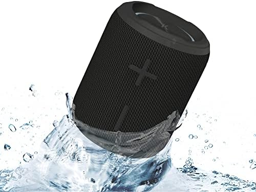

In [11]:
# show example
print()
print("[load] preprocessed schema:", ds.schema())
print()

row = ds.take(1)[0]
print()
print("[load] sample row:", json.dumps(row, indent=2))
print()


resp = requests.get(row["image_url"], timeout=5,
                    headers={"User-Agent": "anyscale-demo/1.0"})
img = Image.open(io.BytesIO(resp.content))
img.thumbnail((256, 256))
img

# vLLM preprocessing

https://docs.ray.io/en/latest/data/working-with-llms.html#multimodal

In [12]:
import io, json, re
import time, base64
from ray.data import ActorPoolStrategy
from ray.data.llm import vLLMEngineProcessorConfig, build_processor
from ray.data.checkpoint import CheckpointConfig

# batch inference checkpointing
ctx = ray.data.DataContext.get_current()
ctx.checkpoint_config = CheckpointConfig(
    id_column="id",
    checkpoint_path=checkpoint_path,
    delete_checkpoint_on_success=False,
)


config = vLLMEngineProcessorConfig(
    model_source="Qwen/Qwen2.5-VL-3B-Instruct",
    engine_kwargs={
        "tensor_parallel_size": 1,
        "pipeline_parallel_size": 1,
        "max_model_len": 4096,
        "trust_remote_code": True,
        "limit_mm_per_prompt": {"image": 1},
        # "should_continue_on_error": True, # if you want row level fault tolerance, like corrupt input image or something, but we filter for those now in preprocessing
    },
    batch_size=16,
    concurrency=1, # autosdcale up to n replicas, if looking for exactly n replicas set (n,n) here (min,max)
    prepare_multimodal_stage={"enabled": True},
    runtime_env={"worker_process_setup_hook": "src._vllm_compat.patch"},
)

prompt = """\
You are a product catalog enrichment assistant. Given a product image and \
the merchant-supplied title, output a JSON object with exactly these keys:

  category:    one short string (e.g. "Wireless Earbuds")
  attributes:  a list of 3 short attribute strings
  search_tags: a list of 5 short search keywords
  description: a single sentence (<= 30 words)

Title: {title}

Return ONLY the JSON object, no commentary.\
"""

def build_messages_url(url, title):
    """Image goes in messages as an OpenAI-spec image_url"""
    return [
        {
            "role": "user", 
            "content": [
                {
                    "type": "image_url", 
                    "image_url": {"url": url}
                },
                {
                    "type": "text",
                    "text": prompt.format(title=title)
                }
            ]
        }
    ]


def vlm_preprocess(row):
    return {
        "id": row["id"],
        "messages": build_messages_url(row["image_url"], row["title"]),
        "sampling_params": {"max_tokens": 256, "temperature": 0.0},
    }

def vlm_postprocess(row):
    return {                                                                                                                             
        "id": row["id"],                     # required for checkpoint id_column                                                         
        "product_id": row["product_id"],                                        
        "title": row["title"],                                                                                                           
        "image_url": row["image_url"],
        "source": row["source"],                                                                                                         
        "raw_output": row["generated_text"],
    }    

vlm_processor = build_processor(
    config, 
    preprocess=vlm_preprocess, 
    postprocess=vlm_postprocess,
    # preprocess_map_kwargs={"num_cpus": 0.5}, # no need to explicitly set unless cpu bound
    # postprocess_map_kwargs={"num_cpus": 0.25},
)

ds = vlm_processor(ds)

# display outputs
outputs = ds.take(limit=2)
for output in outputs:
    print(json.dumps(output, indent=2))

ds.write_parquet(f"{base_dir}/vlm_enriched_{n_rows}.parquet")

INFO 05-04 13:41:43 [importing.py:44] Triton is installed but 0 active driver(s) found (expected 1). Disabling Triton to prevent runtime errors.
INFO 05-04 13:41:43 [importing.py:68] Triton not installed or not compatible; certain GPU-related functions will not be available.


W0504 13:41:44.920000 107325 site-packages/torch/utils/cpp_extension.py:117] No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
2026-05-04 13:41:45,157	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 10.0.64.159:6379...
2026-05-04 13:41:45,157	INFO worker.py:1831 -- Calling ray.init() again after it has already been called.
No cloud storage mirror configured
2026-05-04 13:41:45,297	INFO logging.py:392 -- Registered dataset logger for dataset dataset_55_0
2026-05-04 13:41:45,305	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_55_0. Full logs are in /tmp/ray/session_2026-05-04_10-43-39_675601_3151/logs/ray-data
2026-05-04 13:41:45,306	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_55_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> LimitOperator[limit=50] -> AllToAllOperator[Filter(_has_title_and_image)->Map(_normalize_amazon_row_to_image)->RandomShuffle] -> TaskPoo

(MapWorker(MapBatches(PrepareMultimodalUDF)) pid=27974, ip=10.0.65.202) INFO 05-04 13:41:53 [model.py:541] Resolved architecture: Qwen2_5_VLForConditionalGeneration
(MapWorker(MapBatches(PrepareMultimodalUDF)) pid=27974, ip=10.0.65.202) INFO 05-04 13:41:53 [model.py:1561] Using max model len 128000


(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=8302, ip=10.0.127.201) The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=8302, ip=10.0.127.201) INFO 05-04 13:41:54 [arg_utils.py:1443] Using ray runtime env (env vars redacted): {'_ray_commit': '39dbafeebe26e9c35b6215c37ca3fc8dc007bda3', 'cgroupv2': {}, 'ray_debugger': {'working_dir': '/home/ray/default_cld_g54aiirwj1s8t9ktgzikqur41k/sa-demos/industry-verticals/ecommerce/vlm-batch-embeddings/notebooks'}, 'working_dir': 'gcs://_ray_pkg_dc88a5ad18c36145.zip', 'pip': {'packages': ['peft>=0.12', 'accelerate>=0.34'], 'pip_check': False}, 'env_vars': {'__RAY_WORKER_PROCESS_SETUP_HOOK_ENV_VAR': '***'}, 'worker_process_setup_hook': 'src._vllm_compat.patch'}
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=8302, ip=10.0.127.201) INFO 05-04 13:41:54 [scheduler.py:226] Chunked prefill is enabled with max_num_batched_tokens=2048.
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=8302, ip=10.0.127.201) INFO 05-04 13:41:54 [vllm.py:624] Asynchronous scheduling is enabled.


...

(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173) [vLLM] Elapsed time for batch cce6b60a3584414d91edccf6a4326a64 with size 16: 13.898893554999972


(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173) INFO 05-04 13:50:20 [loggers.py:257] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 114.3 tokens/s, Running: 1 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.2%, Prefix cache hit rate: 0.0%, MM cache hit rate: 0.0%


(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173) [vLLM] Elapsed time for batch 1801945191274c969a6adf30fe877487 with size 16: 14.596688064000034
2026-05-04 13:50:21,418	INFO streaming_executor.py:300 -- ✔️  Dataset dataset_57_0 execution finished in 371.27 seconds


(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173) INFO 05-04 13:50:21 [loggers.py:257] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 38.7 tokens/s, Running: 0 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.0%, Prefix cache hit rate: 0.0%, MM cache hit rate: 0.0%
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173) ERROR 05-04 13:50:21 [core_client.py:605] Engine core proc EngineCore_DP0 died unexpectedly, shutting down client.


INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>
2026-05-04 13:50:22,057	INFO dataset.py:5384 -- Data sink Parquet finished. 50 rows and 28.1KiB data written.


In [13]:
print(json.dumps(output, indent=2))

{
  "id": "672292d3f24e4aa6",
  "product_id": "B0012ZASQS",
  "title": "Canon WP-DC22 Waterproof Case for Canon PowerShot SD1100IS",
  "image_url": "https://m.media-amazon.com/images/I/315msg0Q-dL._AC_.jpg",
  "source": "amazon-reviews-2023",
  "raw_output": "```json\n{\n  \"category\": \"Camera Accessories\",\n  \"attributes\": [\"Waterproof\", \"Canon\", \"PowerShot\"],\n  \"search_tags\": [\"Canon WP-DC22\", \"Waterproof Case\", \"Canon PowerShot SD1100IS\", \"Camera Protection\", \"Underwater Housing\"],\n  \"description\": \"Waterproof Canon WP-DC22 case for Canon PowerShot SD1100IS, protecting your camera in underwater adventures.\"\n}\n```"
}


In [14]:
o = {
  "id": "8b22f3606bcbd0b3",
  "product_id": "B07VJXK7BV",
  "title": "Ares Vision Universal mounting CCTV Security Camera Wall Junction Box Bracket with Hidden Compartment (1 Pack, Wall Dome)",
  "image_url": "https://m.media-amazon.com/images/I/314+6fI-J5L._AC_.jpg",
  "source": "amazon-reviews-2023",
  "raw_output": {
    "category": "CCTV Security Camera Mounting Bracket",
    "attributes": ["Universal Mounting", "Wall Dome", "Hidden Compartment"],
    "search_tags": ["CCTV Mounting Bracket", "Wall Dome Bracket", "Hidden Compartment", "Universal Mounting", "CCTV Security"],
    "description": "Universal CCTV Security Camera Mounting Bracket with Hidden Compartment for Wall Dome Installation"
  }
}

(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173) Exception ignored in: <function vLLMEngineStageUDF.__del__ at 0x765d0ab1a160>
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173) Traceback (most recent call last):
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173)   File "/home/ray/anaconda3/lib/python3.11/site-packages/ray/llm/_internal/batch/stages/vllm_engine_stage.py", line 790, in __del__
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173)   File "/home/ray/anaconda3/lib/python3.11/site-packages/ray/llm/_internal/batch/stages/vllm_engine_stage.py", line 552, in shutdown
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173)   File "/home/ray/anaconda3/lib/python3.11/logging/__init__.py", line 1489, in info
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3210, ip=10.0.91.173)   File "/home/ray/anaconda3/lib/python3.11/logging/__init__.py", line 1634, in _log
(MapWorker(MapBatches(vLLMEngineStageUDF

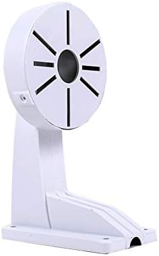

In [15]:
from PIL import Image
import io, requests

resp = requests.get(o["image_url"], timeout=5,
                    headers={"User-Agent": "anyscale-demo/1.0"})
img = Image.open(io.BytesIO(resp.content))
img.thumbnail((256, 256))
img

```
{
  "id": "8b22f3606bcbd0b3",
  "product_id": "B07VJXK7BV",
  "title": "Ares Vision Universal mounting CCTV Security Camera Wall Junction Box Bracket with Hidden Compartment (1 Pack, Wall Dome)",
  "image_url": "https://m.media-amazon.com/images/I/314+6fI-J5L._AC_.jpg",
  "source": "amazon-reviews-2023",
  "raw_output": {
    "category": "CCTV Security Camera Mounting Bracket",
    "attributes": ["Universal Mounting", "Wall Dome", "Hidden Compartment"],
    "search_tags": ["CCTV Mounting Bracket", "Wall Dome Bracket", "Hidden Compartment", "Universal Mounting", "CCTV Security"],
    "description": "Universal CCTV Security Camera Mounting Bracket with Hidden Compartment for Wall Dome Installation"
  }
}

```

In [16]:
print(ds.stats())

Operator 0 ReadFiles: 

Operator 1 ListFiles: 1 tasks executed, 10 blocks produced in 0.69s
* Remote wall time: 64.06us min, 678.06ms max, 68.04ms mean, 680.4ms total
* Remote cpu time: 63.7us min, 287.39ms max, 29.04ms mean, 290.42ms total
* UDF time: 0us min, 0us max, 0.0us mean, 0us total
* Peak heap memory usage (MiB): 487.14 min, 487.18 max, 487 mean
* Output num rows per block: 1 min, 1 max, 1 mean, 10 total
* Output size bytes per block: 114 min, 114 max, 114 mean, 1140 total
* Output rows per task: 10 min, 10 max, 10 mean, 1 tasks used
* Tasks per node: 1 min, 1 max, 1 mean; 1 nodes used
* Operator throughput:
	* Total input num rows: 0 rows
	* Total output num rows: 10 rows
	* Ray Data throughput: 14.5013986214683 rows/s
	* Estimated single task throughput: 14.697316022297398 rows/s

Operator 2 ReadFiles: 10 tasks executed, 39 blocks produced in 10794.7s
* Remote wall time: 8.45ms min, 1.91s max, 676.11ms mean, 26.37s total
* Remote cpu time: 9.92ms min, 818.32ms max, 400.47ms

(autoscaler +14m22s) [autoscaler] Downscaling node i-003c60886d6e20cf8 (node IP: 10.0.70.128) due to node idle termination.
(autoscaler +14m22s) [autoscaler] Downscaling node i-0754f15bc5d3c1488 (node IP: 10.0.65.202) due to node idle termination.
(autoscaler +14m22s) [autoscaler] Cluster resized to {40 CPU, 4 GPU}.
(autoscaler +14m22s) [autoscaler] Downscaling node i-003c60886d6e20cf8 (node IP: 10.0.70.128) due to node idle termination.
(autoscaler +14m22s) [autoscaler] Downscaling node i-003c60886d6e20cf8 (node IP: 10.0.70.128) due to node idle termination.
(autoscaler +14m22s) [autoscaler] Downscaling node i-003c60886d6e20cf8 (node IP: 10.0.70.128) due to node idle termination.
(autoscaler +14m27s) [autoscaler] Downscaling node i-003c60886d6e20cf8 (node IP: 10.0.70.128) due to node idle termination.
(autoscaler +14m27s) [autoscaler] Downscaling node i-003c60886d6e20cf8 (node IP: 10.0.70.128) due to node idle termination.
(autoscaler +14m27s) [autoscaler] Downscaling node i-0754f15bc